# Homework 5

In [ ]:
! pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 95.7 MB/s eta 0:00:00


In [ ]:
# Import packages
from gurobipy import *
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Access google account
drive.mount('/content/drive')

# Configuration
FILE_PATH = '/content/drive/MyDrive/DEA_CLINIC_DATA.xlsx'
df = pd.read_excel(FILE_PATH)

Mounted at /content/drive


In [ ]:
# Define input and output
clinic_id_col = 'Company ID'
output_var = 'number of patients treated'
input_vars = ['medical staff', 'administrative spending', 'inventory usage']
print(df)

    Company ID  number of patients treated  medical staff  \
0            1                         180             16   
1            2                         275             44   
2            3                         180             30   
3            4                         198             23   
4            5                         157             36   
5            6                         166             27   
6            7                         247             36   
7            8                         166             24   
8            9                         149             46   
9           10                         168             28   
10          11                         193             45   
11          12                         237             46   
12          13                         242             36   
13          14                         164             16   
14          15                         251             28   
15          16          

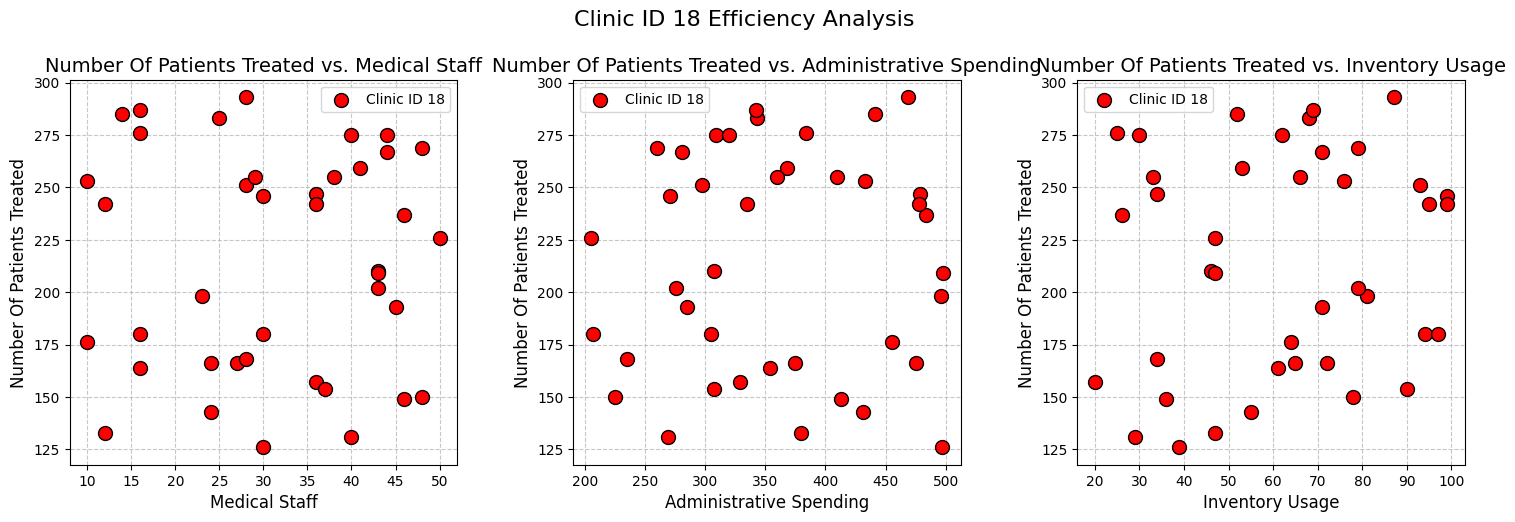

In [ ]:
# Create Scatter Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3)

for i, input_var in enumerate(input_vars):
    ax = axes[i]

    # Highlight Clinic ID 18
    ax.scatter(df[input_var],
               df[output_var],
               label='Clinic ID 18',
               color='red',
               s=100, # size of the marker
               edgecolors='black',
               zorder=5) # Ensure Clinic 18 is on top

    # Set titles and labels
    ax.set_title(f'{output_var.title()} vs. {input_var.title()}', fontsize=14)
    ax.set_xlabel(input_var.title(), fontsize=12)
    ax.set_ylabel(output_var.title(), fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Clinic ID 18 Efficiency Analysis', fontsize=16, y=1.02)
plt.show()

In [ ]:
# Define input and output
clinic_id_col = 'Company ID'
target_clinic_id = 18
output_var = 'number of patients treated'
input_vars = ['medical staff', 'administrative spending', 'inventory usage']

# Define data
N = len(df)
X = df[input_vars].values            # <-- Inputs (matrix)
Y = df[output_var].values            # <-- Output (vector)
num_inputs = X.shape[1]              # number of inputs

# Find index of target clinic
try:
    o_idx = int(df.index[df[clinic_id_col] == target_clinic_id][0])
except IndexError:
    raise ValueError(f"Clinic id {target_clinic_id} not found in column {clinic_id_col}")

# Create DEA model for Clinic 18 efficiency
model = Model('DEA_hw5')

# Variables
phi = model.addVar(vtype=GRB.CONTINUOUS, name="Phi")              # efficiency (≥1 expected)
lambdas = model.addVars(N, name="lambda", lb=0.0)                 # lambdas ≥ 0
model.update()

# Objective Function: maximize phi
model.setObjective(phi, GRB.MAXIMIZE)

# DEA Constraints

# Input constraints: sum_j λ_j * x_ij ≤ x_io, for all inputs i
for i in range(num_inputs):
    model.addConstr(
        sum(lambdas[j] * X[j, i] for j in range(N)) <= X[o_idx, i],
        name=f"input_constr_{i}"
    )

# Output constraint: sum_j λ_j * y_j ≥ φ * y_o
model.addConstr(
    sum(lambdas[j] * Y[j] for j in range(N)) >= phi * Y[o_idx],
    name="output_constr_0"
)

# φ ≥ 1
model.addConstr(phi >= 1.0, name="phi_lower_bound")

# Solve
model.Params.OutputFlag = 1
model.optimize()

# Results
if model.status == GRB.OPTIMAL:
    print(f"\nDEA efficiency (output-oriented) for Clinic {target_clinic_id}: Phi = {phi.X:.4f}")
    lambda_vals = [lambdas[j].X for j in range(N)]
    print("\nNonzero lambdas:")
    for j, val in enumerate(lambda_vals):
        if val > 1e-6:
            print(f"  Clinic {df.loc[j, clinic_id_col]}: {val:.4f}")
else:
    print("Optimization did not reach an optimal solution.")

Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 5 rows, 41 columns and 162 nonzeros
Model fingerprint: 0xea4f9978
Coefficient statistics:
  Matrix range     [1e+00, 5e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 3e+02]
Presolve removed 1 rows and 0 columns
Presolve time: 0.01s
Presolved: 4 rows, 41 columns, 161 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.4692175e+01   1.221836e+03   0.000000e+00      0s
       6    1.0243040e+00   0.000000e+00   0.000000e+00      0s

Solved in 6 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.024304008e+00

DEA efficiency (output-oriented) for Clinic 18: Phi = 1.0243

Nonzero lambdas:
  Clinic 23

In [ ]:
# Define input and output
clinic_id_col = 'Company ID'
target_clinic_id = 18
output_var = 'Satisfied patients'
input_vars = ['medical staff', 'administrative spending', 'inventory usage']

# Define data
N = len(df)
X = df[input_vars].values            # <-- Inputs (matrix)
Y = df[output_var].values            # <-- Output (vector)
num_inputs = X.shape[1]              # number of inputs

# Find index of target clinic
try:
    o_idx = int(df.index[df[clinic_id_col] == target_clinic_id][0])
except IndexError:
    raise ValueError(f"Clinic id {target_clinic_id} not found in column {clinic_id_col}")

# Create DEA model for Clinic 18 efficiency
model = Model('DEA_hw5')

# Variables
phi = model.addVar(vtype=GRB.CONTINUOUS, name="Phi")              # efficiency (≥1 expected)
lambdas = model.addVars(N, name="lambda", lb=0.0)                 # lambdas ≥ 0
model.update()

# Objective Function: maximize phi
model.setObjective(phi, GRB.MAXIMIZE)

# DEA Constraints

# Input constraints: sum_j λ_j * x_ij ≤ x_io, for all inputs i
for i in range(num_inputs):
    model.addConstr(
        sum(lambdas[j] * X[j, i] for j in range(N)) <= X[o_idx, i],
        name=f"input_constr_{i}"
    )

# Output constraint: sum_j λ_j * y_j ≥ φ * y_o
model.addConstr(
    sum(lambdas[j] * Y[j] for j in range(N)) >= phi * Y[o_idx],
    name="output_constr_0"
)

# φ ≥ 1
model.addConstr(phi >= 1.0, name="phi_lower_bound")

# Solve
model.Params.OutputFlag = 1
model.optimize()

# Results
if model.status == GRB.OPTIMAL:
    print(f"\nDEA efficiency (output-oriented) for Clinic {target_clinic_id}: Phi = {phi.X:.4f}")
    lambda_vals = [lambdas[j].X for j in range(N)]
    print("\nNonzero lambdas:")
    for j, val in enumerate(lambda_vals):
        if val > 1e-6:
            print(f"  Clinic {df.loc[j, clinic_id_col]}: {val:.4f}")
else:
    print("Optimization did not reach an optimal solution.")

Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 5 rows, 41 columns and 162 nonzeros
Model fingerprint: 0x1acda740
Coefficient statistics:
  Matrix range     [1e+00, 5e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 3e+02]
Presolve removed 1 rows and 0 columns
Presolve time: 0.01s
Presolved: 4 rows, 41 columns, 161 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.8206637e+01   9.223378e+02   0.000000e+00      0s
       5    1.6607260e+00   0.000000e+00   0.000000e+00      0s

Solved in 5 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.660725980e+00

DEA efficiency (output-oriented) for Clinic 18: Phi = 1.6607

Nonzero lambdas:
  Clinic 1:

In [ ]:
# Shelter data: Demand (kits), Outsourcing Cost ($/kit)
shelter_data = {
    1: {'Demand': 60, 'OutCost': 50},
    2: {'Demand': 45, 'OutCost': 30},
    3: {'Demand': 80, 'OutCost': 60},
    4: {'Demand': 55, 'OutCost': 7},
    5: {'Demand': 90, 'OutCost': 20},
    6: {'Demand': 70, 'OutCost': 40},
    7: {'Demand': 65, 'OutCost': 70},
    8: {'Demand': 50, 'OutCost': 5}
}

# Depot data: Max Capacity (kits), Fixed Opening Cost ($)
depot_data = {
    'North': {'Capacity': 120, 'FixCost': 1000},
    'South': {'Capacity': 200, 'FixCost': 1200},
    'East': {'Capacity': 180, 'FixCost': 1100},
    'West': {'Capacity': 150, 'FixCost': 900}
}

# Sets
SHELTERS = list(shelter_data.keys())
DEPOTS = list(depot_data.keys())

# Parameters
Dem = {s: shelter_data[s]['Demand'] for s in SHELTERS}
OutC = {s: shelter_data[s]['OutCost'] for s in SHELTERS}
Cap = {d: depot_data[d]['Capacity'] for d in DEPOTS}
FixC = {d: depot_data[d]['FixCost'] for d in DEPOTS}

# New Distance Matrix (e.g., in miles, where 1 mile = $1/kit cost)
# Row: Depot, Column: Shelter
distance_matrix = {
    'North': {1: 5, 2: 10, 3: 12, 4: 15, 5: 10, 6: 18, 7: 20, 8: 25},
    'South': {1: 10, 2: 5, 3: 8, 4: 12, 5: 15, 6: 10, 7: 18, 8: 20},
    'East':  {1: 15, 2: 10, 3: 5, 4: 8, 5: 12, 6: 15, 7: 10, 8: 18},
    'West':  {1: 20, 2: 15, 3: 10, 4: 5, 5: 8, 6: 12, 7: 15, 8: 10}
}

# Transportation Cost per kit per unit distance ($1/kit/unit)
COST_PER_UNIT_DISTANCE = 1

# New Parameter: C[d, s] = Transportation Cost ($/kit)
C = {(d, s): distance_matrix[d][s] * COST_PER_UNIT_DISTANCE
     for d in DEPOTS for s in SHELTERS}

In [ ]:
# Model Initialization
model = Model("EmergencyDistributionMILP")
model.ModelSense = GRB.MINIMIZE

# Decision Variables
# X_ds: Kits from depot d to shelter s (Continuous)
X = model.addVars(DEPOTS, SHELTERS, vtype=GRB.CONTINUOUS, name="X", lb=0)
# Y_s: Kits outsourced for shelter s (Continuous)
Y = model.addVars(SHELTERS, vtype=GRB.CONTINUOUS, name="Y", lb=0)
# Z_d: 1 if depot d is opened, 0 otherwise (Binary)
Z = model.addVars(DEPOTS, vtype=GRB.BINARY, name="Z")

# Objective Function
# Minimize: Fixed Cost + Outsourcing Cost + Transportation Cost
transport_cost = quicksum(C[d, s] * X[d, s] for d in DEPOTS for s in SHELTERS)

objective = (
    quicksum(FixC[d] * Z[d] for d in DEPOTS) +
    quicksum(OutC[s] * Y[s] for s in SHELTERS) +
    transport_cost
)
model.setObjective(objective)

# Constraints
# Demand Satisfaction Constraint (for each shelter s)
# The total kits received (from depots and outsourcing) must meet demand.
for s in SHELTERS:
    model.addConstr(quicksum(X[d, s] for d in DEPOTS) + Y[s] == Dem[s], f"Demand_Shelter_{s}")

# Depot Capacity/Linkage Constraint (for each depot d)
# Total kits shipped from a depot cannot exceed its capacity, and only if it's opened.
for d in DEPOTS:
    model.addConstr(quicksum(X[d, s] for s in SHELTERS) <= Cap[d] * Z[d], f"Capacity_Depot_{d}")

# Solve
model.optimize()

# Solution Summary and Output Formatting (if solved) ---
if model.status == GRB.OPTIMAL:
        # (1) Kits delivered
        print("\n(1) Kits Delivered from Each Depot to Each Shelter (X_ds):")
        delivery_data = []
        for d in DEPOTS:
            for s in SHELTERS:
                delivery = X[d, s].X
                if delivery > 1e-5:
                    delivery_data.append(f"From {d} to Shelter {s}: {delivery:.0f} kits")
        print("\n".join(delivery_data) if delivery_data else "No kits delivered from depots.")

        # (2) Depots Opened
        print("\n(2) Depots Opened (Z_d):")
        opened_depots = [d for d in DEPOTS if Z[d].X > 0.5]
        print(f"Opened Depots: {', '.join(opened_depots) if opened_depots else 'None'}")

        # (3) Kits Outsourced
        print("\n(3) Kits Outsourced (Y_s):")
        outsourced_kits = [f"Shelter {s}: {Y[s].X:.0f} kits" for s in SHELTERS if Y[s].X > 1e-5]
        print("\n".join(outsourced_kits) if outsourced_kits else "Total outsourced kits: 0")

        # (4) Total Cost Broken Down
        fixed_cost = sum(FixC[d] * Z[d].X for d in DEPOTS)
        outsourcing_cost = sum(OutC[s] * Y[s].X for s in SHELTERS)
        total_cost = model.ObjVal

        print("\n(4) Total Cost Broken Down by Component:")
        print(f"Fixed Opening Cost: ${fixed_cost:,.2f}")
        print(f"Outsourcing Cost: ${outsourcing_cost:,.2f}")
        print(f"TOTAL COST: ${total_cost:,.2f}")

else:
        print(f"\nOptimization was not successful. Status: {model.status}")

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 12 rows, 44 columns and 76 nonzeros
Model fingerprint: 0xce4891fd
Variable types: 40 continuous, 4 integer (4 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [5e+00, 1e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [4e+01, 9e+01]
Presolve removed 2 rows and 15 columns
Presolve time: 0.00s
Presolved: 10 rows, 29 columns, 53 nonzeros
Variable types: 25 continuous, 4 integer (4 binary)
Found heuristic solution: objective 7720.0000000

Root relaxation: objective 6.246111e+03, 7 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 6246.111

In [ ]:
# **Crucial Assumption**: All depots are FIXED as OPEN (Z_d = 1)
D_OPEN = DEPOTS

# Model Initialization (Dual Maximization)
dual_model = Model("EmergencyDistributionDualLP")
dual_model.ModelSense = GRB.MAXIMIZE

# Dual Decision Variables
# U_s: Dual variable for Demand constraint (Unrestricted in Sign)
# Represents the marginal value of satisfying demand at shelter s.
U = dual_model.addVars(SHELTERS, vtype=GRB.CONTINUOUS, name="U")
# V_d: Dual variable for Capacity constraint (Non-positive: <= 0)
# Represents the marginal cost of using capacity at open depot d.
V = dual_model.addVars(D_OPEN, vtype=GRB.CONTINUOUS, name="V", ub=0) # Set upper bound to 0

# Dual Objective Function
# Maximize: Sum of Demand * U_s + Sum of Capacity * V_d
objective = (quicksum(Dem[s] * U[s] for s in SHELTERS) + quicksum(Cap[d] * V[d] for d in D_OPEN))
dual_model.setObjective(objective)

# Dual Constraints
# Constraint for Primal Variable X_ds (Flow)
# U_s + V_d <= C_ds
for d in D_OPEN:
    for s in SHELTERS:
        dual_model.addConstr(
            U[s] + V[d] <= C[d, s],
            f"Dual_Flow_d{d}_s{s}")

# Constraint for Primal Variable Y_s (Outsourcing)
# U_s <= OutC_s
for s in SHELTERS:
    dual_model.addConstr(
        U[s] <= OutC[s],
        f"Dual_Outsourcing_s{s}")

# Solve
dual_model.optimize()

# Solution Summary and Interpretation
if dual_model.status == GRB.OPTIMAL:
        print("\nDual Problem Solved Successfully.")
        print("-" * 40)
        print(f"Dual Objective Value (Maximized): ${dual_model.ObjVal:,.2f}")

        # Total cost includes the fixed opening cost from the Primal solution
        # The Dual objective only captures variable costs.
        FIXED_COST = 1000 + 1200 + 1100 + 900 # $4,200
        print(f"Total Cost (Primal Obj = Dual Obj + Fixed Cost): ${dual_model.ObjVal + FIXED_COST:,.2f}")

        print("\nShadow Prices (Marginal Value of Demand U_s):")
        for s in SHELTERS:
            print(f"U_s{s} (Shelter {s}): {U[s].X:.2f} $/kit")

        print("\nShadow Costs (Marginal Cost of Capacity V_d):")
        for d in D_OPEN:
            print(f"V_{d}: {V[d].X:.2f} $/kit")

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 40 rows, 12 columns and 72 nonzeros
Model fingerprint: 0xe08a324f
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [4e+01, 2e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+00, 7e+01]
Presolve removed 40 rows and 12 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.5200000e+03   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.02 seconds (0.00 work units)
Optimal objective  3.520000000e+03

Dual Problem Solved Successfully.
----------------------------------------
Dual Objective Value (Maximized): $3,520.00
Total Cost (Primal Obj = Dual Obj + Fixed Cost): $7,720.00

Shadow Prices (

# Homework 6

In [ ]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd

# --- 1. Define Data Sets and Parameters ---

# Sets
S = ['X', 'Y', 'Z']  # Suppliers
H = ['A', 'B', 'C']  # Hubs

# Parameters (Costs and Availability/Requirements)

# Table 1: Transportation costs, per fabric roll, from suppliers to hubs (C_sh)
# Keys are (supplier, hub)
cost_supplier_hub = {
    ('X', 'A'): 180, ('X', 'B'): 240, ('X', 'C'): 310,
    ('Y', 'A'): 220, ('Y', 'B'): 200, ('Y', 'C'): 250,
    ('Z', 'A'): 300, ('Z', 'B'): 180, ('Z', 'C'): 230
}

# Table 1: Supplier availability (A_s)
availability = {
    'X': 60,
    'Y': 100,
    'Z': 170
}

# Table 1: Hub requirements (R_h)
requirements = {
    'A': 90,
    'B': 80,
    'C': 60
}

# Table 2: Transportation costs, per roll, between manufacturing hubs (T_hh')
# Keys are (from_hub, to_hub). Note: costs are one-way.
cost_hub_hub = {
    ('A', 'B'): 12,  ('A', 'C'): 17,
    ('B', 'A'): 20,  ('B', 'C'): 10,
    ('C', 'A'): 15,  ('C', 'B'): 18
}

In [ ]:
# --- 2. Create the Gurobi Model ---

# Create a new model
model = gp.Model("Fabric_Transportation")

# --- 3. Define Decision Variables ---

# x_sh: Rolls shipped from supplier s to hub h
x = model.addVars(S, H, vtype=GRB.INTEGER, name="x_sh")

# y_hh': Rolls transferred from hub h to hub h'
# Use a list of valid (h, h') pairs where h != h'
hub_pairs = [(h1, h2) for h1 in H for h2 in H if h1 != h2]
y = model.addVars(hub_pairs, vtype=GRB.INTEGER, name="y_hh'")

# --- 4. Set Objective Function (Minimize Total Cost) ---

# Supplier-to-hub cost
cost_supplier = sum(cost_supplier_hub[s, h] * x[s, h] for s in S for h in H)

# Hub-to-hub transfer cost
cost_transfer = sum(cost_hub_hub[h1, h2] * y[h1, h2] for h1, h2 in hub_pairs)

model.setObjective(cost_supplier + cost_transfer, GRB.MINIMIZE)

# --- 5. Add Constraints ---

# 1. Supplier Capacity Constraints
# Total shipped from each supplier s must be <= A_s
for s in S:
    model.addConstr(sum(x[s, h] for h in H) <= availability[s], name=f"Supply_Cap_{s}")

# 2. Hub Flow Balance and Requirement Constraints
# (Supply In) - (Supply Out) = Requirement
# (x_sh + y_h'h) - (y_hh') = R_h
for h in H:
        supply_in_from_suppliers = sum(x[s, h] for s in S)
        supply_in_from_hubs = sum(y[h_prime, h] for h_prime in H if h_prime != h)
        supply_out_to_hubs = sum(y[h, h_prime] for h_prime in H if h_prime != h)

        model.addConstr(
            (supply_in_from_suppliers + supply_in_from_hubs - supply_out_to_hubs) == requirements[h],
            name=f"Hub_Balance_{h}"
    )

# --- 6. Optimize the Model ---
model.optimize()

Restricted license - for non-production use only - expires 2026-11-23
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 6 rows, 15 columns and 30 nonzeros
Model fingerprint: 0xa99b604c
Variable types: 0 continuous, 15 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+01, 3e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+01, 2e+02]
Found heuristic solution: objective 60400.000000
Presolve time: 0.00s
Presolved: 6 rows, 15 columns, 30 nonzeros
Variable types: 0 continuous, 15 integer (0 binary)

Root relaxation: objective 4.260000e+04, 6 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Nod

In [ ]:
if model.status == GRB.OPTIMAL:
        print("\n" + "="*50)
        print(f"Optimal Total Transportation Cost: ${model.ObjVal:,.2f}")
        print("="*50 + "\n")

        # Prepare for the output table
        shipping_data = []

        # Get optimal supplier-to-hub shipments
        for s in S:
            for h in H:
                quantity = x[s, h].X
                if quantity > 0:
                    cost = cost_supplier_hub[s, h]
                    shipping_data.append({
                        'From/To': f"Supplier {s} -> Hub {h}",
                        'Quantity (rolls)': int(quantity),
                        'Cost per Roll ($)': cost,
                        'Total Cost ($)': quantity * cost
                    })

        # Get optimal hub-to-hub transfers
        for h1, h2 in hub_pairs:
            quantity = y[h1, h2].X
            if quantity > 0:
                cost = cost_hub_hub[h1, h2]
                shipping_data.append({
                    'From/To': f"Hub {h1} -> Hub {h2}",
                    'Quantity (rolls)': int(quantity),
                    'Cost per Roll ($)': cost,
                    'Total Cost ($)': quantity * cost
                })

        # Create DataFrame and format
        df = pd.DataFrame(shipping_data)
        df['Total Cost ($)'] = df['Total Cost ($)'].map('{:,.2f}'.format)
        df['Quantity (rolls)'] = df['Quantity (rolls)'].astype(int)

        print("Optimal Shipment Quantities Table:")
        print(df.to_markdown(index=False))
        print("\n")

        # Summarize Findings
        print("Summary of Optimal Shipping Plan:")
        total_shipped_from_suppliers = {}
        for s in S:
            shipped = sum(x[s, h].X for h in H)
            total_shipped_from_suppliers[s] = shipped

        print("- Supplier Shipments:")
        for s in S:
            shipments = [f"{int(x[s, h].X)} rolls to Hub {h}" for h in H if x[s, h].X > 0]
            if shipments:
                print(f"  * Supplier {s} ships: " + ", ".join(shipments) +
                      f" (Used {int(total_shipped_from_suppliers[s])}/{availability[s]} capacity)")
            else:
                 print(f"  * Supplier {s} ships: None (Used 0/{availability[s]} capacity)")

        print("\n- Hub Transfers:")
        for h1, h2 in hub_pairs:
            quantity = y[h1, h2].X
            if quantity > 0:
                print(f"  * {int(quantity)} rolls are transferred from Hub {h1} to Hub {h2}.")


Optimal Total Transportation Cost: $42,600.00

Optimal Shipment Quantities Table:
| From/To             |   Quantity (rolls) |   Cost per Roll ($) | Total Cost ($)   |
|:--------------------|-------------------:|--------------------:|:-----------------|
| Supplier X -> Hub A |                 60 |                 180 | 10,800.00        |
| Supplier Z -> Hub B |                170 |                 180 | 30,600.00        |
| Hub B -> Hub A      |                 30 |                  20 | 600.00           |
| Hub B -> Hub C      |                 60 |                  10 | 600.00           |


Summary of Optimal Shipping Plan:
- Supplier Shipments:
  * Supplier X ships: 60 rolls to Hub A (Used 60/60 capacity)
  * Supplier Y ships: None (Used 0/100 capacity)
  * Supplier Z ships: 170 rolls to Hub B (Used 170/170 capacity)

- Hub Transfers:
  * 30 rolls are transferred from Hub B to Hub A.
  * 60 rolls are transferred from Hub B to Hub C.


In [ ]:
# NEW REDUCED Availability (A'_s)
new_availability = {
    'X': int(60 * 0.70),    # 42 rolls
    'Y': int(100 * 0.50),   # 50 rolls
    'Z': int(170 * 0.80)    # 136 rolls
}

PENALTY = 10000 # Penalty for unmet demand

model = gp.Model("Reduced_Supply_Transportation")
hub_pairs = [(h1, h2) for h1 in H for h2 in H if h1 != h2]

# --- 3. Define Decision Variables ---
x = model.addVars(S, H, vtype=GRB.INTEGER, name="x_sh")
y = model.addVars(hub_pairs, vtype=GRB.INTEGER, name="y_hh'")
u = model.addVars(H, vtype=GRB.INTEGER, name="u_h") # New Unmet Demand variable

# --- 4. Set Objective Function (Minimize Total Cost + Penalty) ---
cost_supplier = sum(cost_supplier_hub[s, h] * x[s, h] for s in S for h in H)
cost_transfer = sum(cost_hub_hub[h1, h2] * y[h1, h2] for h1, h2 in hub_pairs)
cost_penalty = sum(PENALTY * u[h] for h in H) # Penalty term

model.setObjective(cost_supplier + cost_transfer + cost_penalty, GRB.MINIMIZE)

# --- 5. Add Constraints ---

# 1. Supplier Capacity Constraints (UPDATED with new_availability)
for s in S:
    model.addConstr(sum(x[s, h] for h in H) <= new_availability[s], name=f"Supply_Cap_{s}")

# 2. Hub Flow Balance and Requirement Constraints (UPDATED with u_h)
# Net Flow In = Required Demand - Unmet Demand (R_h - u_h)
for h in H:
    supply_in_from_suppliers = sum(x[s, h] for s in S)
    supply_in_from_hubs = sum(y[h_prime, h] for h_prime in H if h_prime != h)
    supply_out_to_hubs = sum(y[h, h_prime] for h_prime in H if h_prime != h)

    model.addConstr(
        (supply_in_from_suppliers + supply_in_from_hubs - supply_out_to_hubs) == requirements[h] - u[h],
        name=f"Hub_Balance_{h}"
  )

# --- 6. Optimize the Model and Present Results ---
model.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 6 rows, 18 columns and 33 nonzeros
Model fingerprint: 0xb5614ec0
Variable types: 0 continuous, 18 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+01, 1e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+01, 1e+02]
Found heuristic solution: objective 2300000.0000
Presolve time: 0.00s
Presolved: 6 rows, 18 columns, 33 nonzeros
Variable types: 0 continuous, 18 integer (0 binary)

Root relaxation: objective 6.356000e+04, 9 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0    63560.000000 63560.0000  0.00%

In [ ]:
if model.status == GRB.OPTIMAL:
        print("\n" + "="*50)
        print(f"Optimal Total Transportation Cost: ${model.ObjVal:,.2f}")
        print("="*50 + "\n")

        # Prepare for the output table
        shipping_data = []

        # Get optimal supplier-to-hub shipments
        for s in S:
            for h in H:
                quantity = x[s, h].X
                if quantity > 0:
                    cost = cost_supplier_hub[s, h]
                    shipping_data.append({
                        'From/To': f"Supplier {s} -> Hub {h}",
                        'Quantity (rolls)': int(quantity),
                        'Cost per Roll ($)': cost,
                        'Total Cost ($)': quantity * cost
                    })

        # Get optimal hub-to-hub transfers
        for h1, h2 in hub_pairs:
            quantity = y[h1, h2].X
            if quantity > 0:
                cost = cost_hub_hub[h1, h2]
                shipping_data.append({
                    'From/To': f"Hub {h1} -> Hub {h2}",
                    'Quantity (rolls)': int(quantity),
                    'Cost per Roll ($)': cost,
                    'Total Cost ($)': quantity * cost
                })

        # Create DataFrame and format
        df = pd.DataFrame(shipping_data)
        df['Total Cost ($)'] = df['Total Cost ($)'].map('{:,.2f}'.format)
        df['Quantity (rolls)'] = df['Quantity (rolls)'].astype(int)

        print("Optimal Shipment Quantities Table:")
        print(df.to_markdown(index=False))
        print("\n")

        # Summarize Findings
        print("Summary of Optimal Shipping Plan:")
        total_shipped_from_suppliers = {}
        for s in S:
            shipped = sum(x[s, h].X for h in H)
            total_shipped_from_suppliers[s] = shipped

        print("- Supplier Shipments:")
        for s in S:
            shipments = [f"{int(x[s, h].X)} rolls to Hub {h}" for h in H if x[s, h].X > 0]
            if shipments:
                print(f"  * Supplier {s} ships: " + ", ".join(shipments) +
                      f" (Used {int(total_shipped_from_suppliers[s])}/{availability[s]} capacity)")
            else:
                 print(f"  * Supplier {s} ships: None (Used 0/{availability[s]} capacity)")

        print("\n- Hub Transfers:")
        for h1, h2 in hub_pairs:
            quantity = y[h1, h2].X
            if quantity > 0:
                print(f"  * {int(quantity)} rolls are transferred from Hub {h1} to Hub {h2}.")


Optimal Total Transportation Cost: $63,560.00

Optimal Shipment Quantities Table:
| From/To             |   Quantity (rolls) |   Cost per Roll ($) | Total Cost ($)   |
|:--------------------|-------------------:|--------------------:|:-----------------|
| Supplier X -> Hub A |                 42 |                 180 | 7,560.00         |
| Supplier Y -> Hub A |                 46 |                 220 | 10,120.00        |
| Supplier Y -> Hub B |                  4 |                 200 | 800.00           |
| Supplier Z -> Hub B |                136 |                 180 | 24,480.00        |
| Hub B -> Hub C      |                 60 |                  10 | 600.00           |


Summary of Optimal Shipping Plan:
- Supplier Shipments:
  * Supplier X ships: 42 rolls to Hub A (Used 42/60 capacity)
  * Supplier Y ships: 46 rolls to Hub A, 4 rolls to Hub B (Used 50/100 capacity)
  * Supplier Z ships: 136 rolls to Hub B (Used 136/170 capacity)

- Hub Transfers:
  * 60 rolls are transferred fr

In [ ]:
# --- 1. Data Definition ---

# Sets
P = ['Reg', 'Spec']
H = [1, 2, 3]
W = [1, 2, 3]
C = [1, 2, 3, 4, 5]

# Table 3: Hub to Warehouse Transportation Costs (C_hw)
cost_hw = {
    (1, 1): 100, (1, 2): 370, (1, 3): 90,
    (2, 1): 225, (2, 2): 450, (2, 3): 300,
    (3, 1): 150, (3, 2): 400, (3, 3): 200
}

# Table 4: Warehouse to Customer Transportation Costs (C_wc)
cost_wc = {
    (1, 1): 50, (1, 2): 70, (1, 3): 30, (1, 4): 25, (1, 5): 50,
    (2, 1): 60, (2, 2): 40, (2, 3): 75, (2, 4): 40, (2, 5): 75,
    (3, 1): 50, (3, 2): 35, (3, 3): 30, (3, 4): 80, (3, 5): 50
}

# Table 5: Weekly Demand (D_cp)
demand = {
    (1, 'Reg'): 200, (1, 'Spec'): 100,
    (2, 'Reg'): 250, (2, 'Spec'): 50,
    (3, 'Reg'): 150, (3, 'Spec'): 100,
    (4, 'Reg'): 100, (4, 'Spec'): 200,
    (5, 'Reg'): 200, (5, 'Spec'): 350
}
# Total demand: 1600 orders

# Table 6: Unmet Demand Penalty Cost (M_cp)
penalty = {
    (1, 'Reg'): 850, (1, 'Spec'): 250,
    (2, 'Reg'): 600, (2, 'Spec'): 600,
    (3, 'Reg'): 950, (3, 'Spec'): 50,
    (4, 'Reg'): 150, (4, 'Spec'): 650,
    (5, 'Reg'): 50,  (5, 'Spec'): 1000
}

# Table 7: Max Hub to Warehouse Orders (K_hw)
cap_hw = {
    (1, 1): 50, (1, 2): 30, (1, 3): 60,
    (2, 1): 40, (2, 2): 35, (2, 3): 85,
    (3, 1): 45, (3, 2): 50, (3, 3): 55
}
# Total capacity Hub->Warehouse: 450 orders

# Table 8: Max Warehouse to Customer Orders (K_wc)
cap_wc = {
    (1, 1): 40, (1, 2): 35, (1, 3): 25, (1, 4): 50, (1, 5): 25,
    (2, 1): 45, (2, 2): 60, (2, 3): 25, (2, 4): 10, (2, 5): 60,
    (3, 1): 65, (3, 2): 30, (3, 3): 40, (3, 4): 20, (3, 5): 50
}
# Total capacity Warehouse->Customer: 580 orders

In [ ]:
# --- 2. Model Creation ---
model = gp.Model("MultiStage_Transportation")

# --- 3. Decision Variables ---
# x_hwp: Hub h to Warehouse w, Product p
x = model.addVars(H, W, P, vtype=GRB.INTEGER, name="x")
# y_wcp: Warehouse w to Customer c, Product p
y = model.addVars(W, C, P, vtype=GRB.INTEGER, name="y")
# u_cp: Unmet demand at Customer c, Product p
u = model.addVars(C, P, vtype=GRB.INTEGER, name="u")

# --- 4. Objective Function (Minimize Total Cost) ---

# Transportation Cost (Hub -> Warehouse)
cost1 = gp.quicksum(cost_hw[h, w] * x[h, w, p] for h in H for w in W for p in P)

# Transportation Cost (Warehouse -> Customer)
cost2 = gp.quicksum(cost_wc[w, c] * y[w, c, p] for w in W for c in C for p in P)

# Penalty Cost
cost_penalty = gp.quicksum(penalty[c, p] * u[c, p] for c in C for p in P)

model.setObjective(cost1 + cost2 + cost_penalty, GRB.MINIMIZE)

# --- 5. Constraints ---

# 1. Hub-to-Warehouse Capacity (Combined Products)
for h in H:
    for w in W:
        model.addConstr(gp.quicksum(x[h, w, p] for p in P) <= cap_hw[h, w], name=f"Cap_HW_{h}_{w}")

# 2. Warehouse-to-Customer Capacity (Combined Products)
for w in W:
    for c in C:
        model.addConstr(gp.quicksum(y[w, c, p] for p in P) <= cap_wc[w, c], name=f"Cap_WC_{w}_{c}")

# 3. Warehouse Flow Balance (Total In = Total Out)
# The total orders of product p shipped into warehouse w must equal the total orders shipped out.
for w in W:
    for p in P:
        total_in = gp.quicksum(x[h, w, p] for h in H)
        total_out = gp.quicksum(y[w, c, p] for c in C)
        model.addConstr(total_in == total_out, name=f"Flow_Balance_{w}_{p}")

# 4. Customer Demand (Demand = Supply + Unmet Demand)
# The demand for product p at customer c must be met by shipments from all warehouses plus any unmet demand.
for c in C:
    for p in P:
        total_supply = gp.quicksum(y[w, c, p] for w in W)
        model.addConstr(total_supply + u[c, p] == demand[c, p], name=f"Demand_{c}_{p}")

# --- 6. Optimize the Model ---
model.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 40 rows, 58 columns and 136 nonzeros
Model fingerprint: 0xd59396d0
Variable types: 0 continuous, 58 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+01, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 4e+02]
Found heuristic solution: objective 1027500.0000
Presolve removed 8 rows and 10 columns
Presolve time: 0.01s
Presolved: 32 rows, 48 columns, 102 nonzeros
Variable types: 0 continuous, 48 integer (0 binary)

Root relaxation: objective 7.672250e+05, 24 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0      

In [ ]:
# --- 7. Report Results ---

if model.status == GRB.OPTIMAL:

        # Calculate Costs
        transport_cost_total = cost1.getValue() + cost2.getValue()
        penalty_cost_total = cost_penalty.getValue()
        total_min_cost = model.ObjVal

        # Extract Shipments (Hub -> Warehouse)
        hw_shipments = [{'Hub': h, 'Warehouse': w, 'Product': p, 'Orders': x[h, w, p].X}
                        for h in H for w in W for p in P if x[h, w, p].X > 0.5]
        df_hw = pd.DataFrame(hw_shipments)

        # Extract Shipments (Warehouse -> Customer)
        wc_shipments = [{'Warehouse': w, 'Customer': c, 'Product': p, 'Orders': y[w, c, p].X}
                        for w in W for c in C for p in P if y[w, c, p].X > 0.5]
        df_wc = pd.DataFrame(wc_shipments)

        # Extract Unmet Demand
        unmet_demand = [{'Customer': c, 'Product': p, 'Unmet Orders': u[c, p].X}
                        for c in C for p in P if u[c, p].X > 0.5]
        df_unmet = pd.DataFrame(unmet_demand)

        # Output summary and tables
        print("\n" + "="*80)
        print("OPTIMAL TRANSPORTATION STRATEGY (Reduced Capacity)")
        print("="*80)

        print("\n--- 1. Cost Summary ---")
        print(f"Total Transportation Cost: ${transport_cost_total:,.2f}")
        print(f"Total Penalty Cost:        ${penalty_cost_total:,.2f}")
        print(f"Overall Minimum Cost:      ${total_min_cost:,.2f}")

        print("\n--- 2. Optimal Hub-to-Warehouse Shipments ---")
        print(df_hw.to_markdown(index=False, floatfmt=".0f"))

        print("\n--- 3. Optimal Warehouse-to-Customer Shipments ---")
        print(df_wc.to_markdown(index=False, floatfmt=".0f"))

        print("\n--- 4. Unmet Demand Disaggregated ---")
        if not df_unmet.empty:
            print(df_unmet.to_markdown(index=False, floatfmt=".0f"))
        else:
            print("No demand was left unmet.")

else:
        print(f"Model did not solve to optimality. Status: {model.status}")


OPTIMAL TRANSPORTATION STRATEGY (Reduced Capacity)

--- 1. Cost Summary ---
Total Transportation Cost: $132,225.00
Total Penalty Cost:        $635,000.00
Overall Minimum Cost:      $767,225.00

--- 2. Optimal Hub-to-Warehouse Shipments ---
|   Hub |   Warehouse | Product   |   Orders |
|------:|------------:|:----------|---------:|
|     1 |           1 | Reg       |       50 |
|     1 |           2 | Reg       |        5 |
|     1 |           2 | Spec      |       25 |
|     1 |           3 | Reg       |       60 |
|     2 |           1 | Reg       |       15 |
|     2 |           1 | Spec      |       25 |
|     2 |           2 | Spec      |       35 |
|     2 |           3 | Reg       |       15 |
|     2 |           3 | Spec      |       70 |
|     3 |           1 | Spec      |       45 |
|     3 |           2 | Reg       |       50 |
|     3 |           3 | Reg       |       55 |

--- 3. Optimal Warehouse-to-Customer Shipments ---
|   Warehouse |   Customer | Product   |   Orders